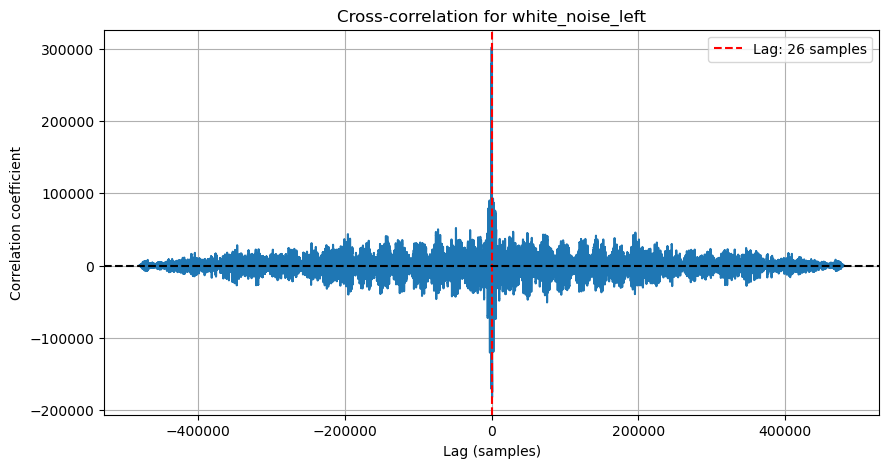

Fichier : white_noise_left
---------------------------------
Décalage : 26 échantillons (0.54 ms)


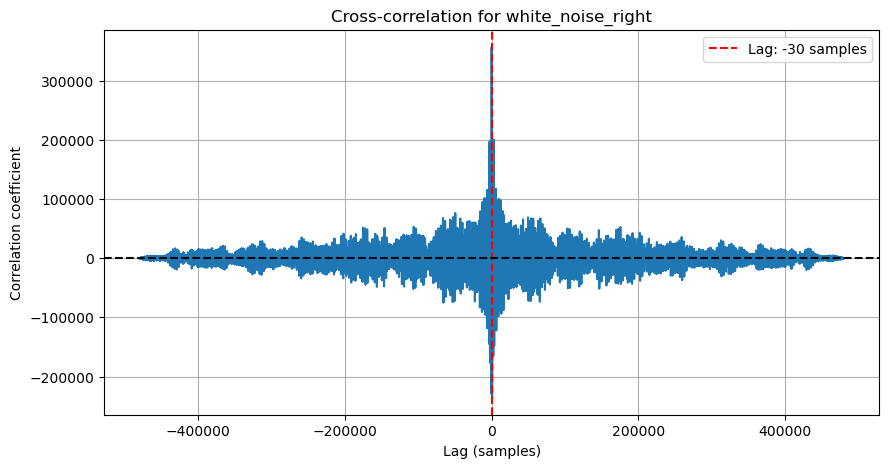

Fichier : white_noise_right
---------------------------------
Décalage : -30 échantillons (-0.62 ms)


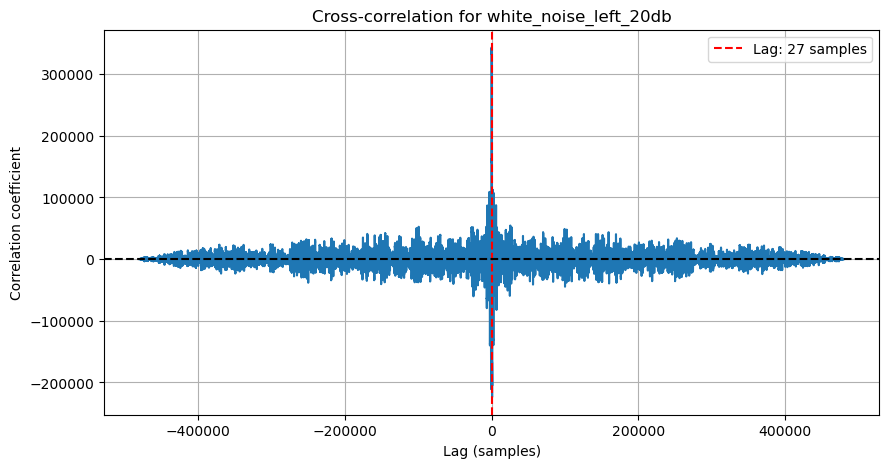

Fichier : white_noise_left_20db
---------------------------------
Décalage : 27 échantillons (0.56 ms)


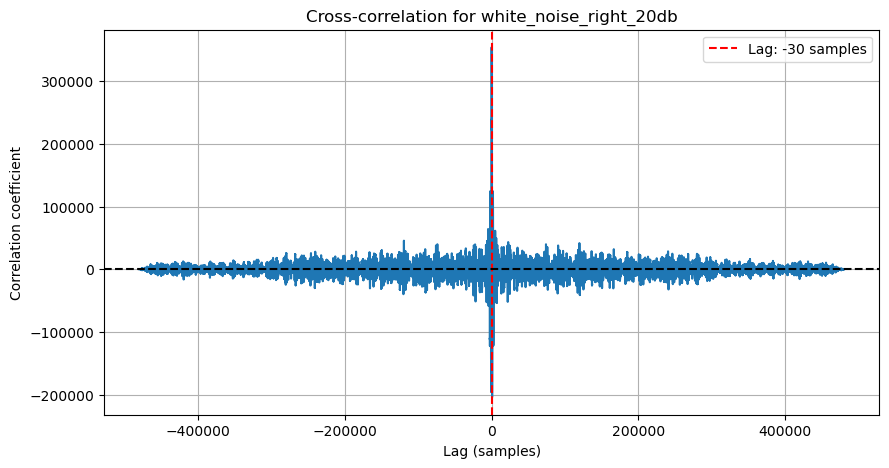

Fichier : white_noise_right_20db
---------------------------------
Décalage : -30 échantillons (-0.62 ms)


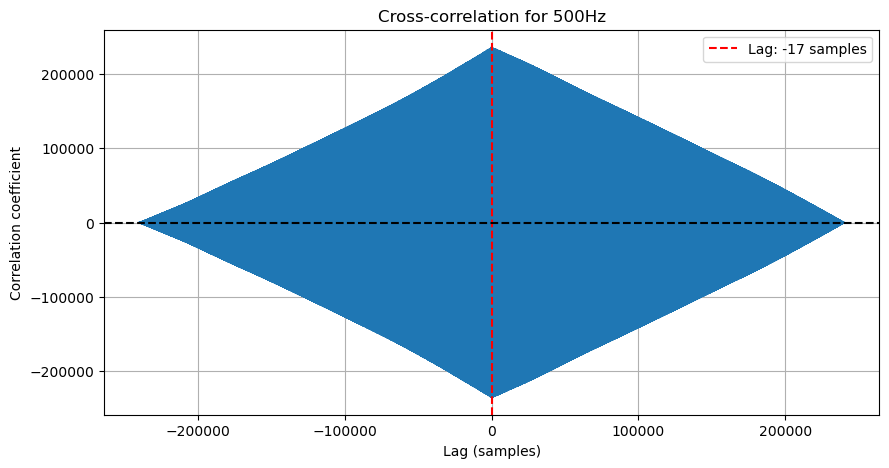

Fichier : 500Hz
---------------------------------
Décalage : -17 échantillons (-0.35 ms)
Résultats finaux :
Décalage moyen : (0.54 ms)


In [2]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
from scipy.signal import correlate

# === 1. Charger le fichier audio .wav ===
lag_samples = []
samples = ["white_noise_left", "white_noise_right", "white_noise_left_20db", "white_noise_right_20db", "500Hz"]
for sample in samples:
    sample_rate, stereo_data = wav.read(f"white_noise/{sample}.wav")

    # === 2. Extraire les canaux gauche et droit ===
    left_channel = stereo_data[:, 0]
    right_channel = stereo_data[:, 1]

    # === 3. (Optionnel) Normalisation
    def normalize(signal):
        return (signal - np.mean(signal)) / (np.std(signal) + 1e-10)

    left_channel = normalize(left_channel)
    right_channel = normalize(right_channel)

    # === 4. Cross-corrélation
    cross_corr = correlate(left_channel, right_channel, mode='full')
    lags = np.arange(-len(left_channel) + 1, len(left_channel))

    # === 5. Trouver le pic de corrélation
    max_corr_index = np.argmax(cross_corr)
    lag_in_samples = lags[max_corr_index]
    lag_in_ms = lag_in_samples / sample_rate * 1000  # conversion en ms
    plt.figure(figsize=(10, 5))
    plt.plot(lags, cross_corr)
    plt.title(f"Cross-correlation for {sample}")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Correlation coefficient")
    plt.axvline(x=lag_in_samples, color='r', linestyle='--', label=f'Lag: {lag_in_samples} samples')
    plt.axhline(y=0, color='k', linestyle='--')
    plt.legend()
    plt.grid()
    plt.show()
    
    lag_samples.append(lag_in_ms)

    # === 7. Impression du décalage
    print(f"======================================")
    print(f"Fichier : {sample}")
    print("---------------------------------")
    print(f"Décalage : {lag_in_samples} échantillons ({lag_in_ms:.2f} ms)")
lag_tot = 0
for lag in lag_samples:
    lag_tot += np.abs(lag)
lag_tot /= len(lag_samples)
print("======================================")
print("Résultats finaux :")
print("======================================")
print(f"Décalage moyen : ({lag_tot:.2f} ms)")


In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [7]:
# Parameters
sample_rate = 48000  # Sample rate in Hz


In [15]:

def BPF(f_min, f_max, sample_rate, nb_band, BW):
    """
    Band-pass filter design using the Butterworth filter.
    f_min: Minimum frequency of the band
    f_max: Maximum frequency of the band
    sample_rate: Sample rate of the signal
    nb_band: Number of bands to create
    BW: Bandwidth factor
    """
    duration = 3  # Duration of the white noise in seconds

    # Generate white noise
    noise = np.random.normal(0, 1, sample_rate * duration)

    # Normalize the white noise
    noise = noise / np.max(np.abs(noise))

    # Convert the white noise to a 16-bit format
    noise = (noise * 2**15).astype(np.int16)
    
    y = []
    f_center = np.geomspace(f_min, f_max, nb_band)
    for center in f_center:

        w0 = (2*np.pi * center) / sample_rate
        alpha = np.sin(w0) * np.sinh((np.log(2)/2) * BW * (w0 / np.sin(w0)))

        a0 = 1 + alpha
        b0 = (np.sin(w0) / 2) / a0
        b1 = 0
        b2 = (-np.sin(w0) / 2) / a0
        a1 = (-2 * np.cos(w0)) / a0
        a2 = (1 - alpha) / a0 

        xn1 = 0
        xn2 = 0
        yn1 = 0
        yn2 = 0

        yn_band = []
        for xn in noise:
            yn = b0 * xn + b1 * xn1 + b2 * xn2 - a1 * yn1 - a2 * yn2
            xn2 = xn1
            xn1 = xn
            yn2 = yn1
            yn1 = yn
            yn_band.append(yn)
        y.append(yn_band)

    return y, f_center




Band 1: Center Frequency = 100.00 Hz, Max FFT Amplitude at 99.67 Hz
Band 2: Center Frequency = 107.71 Hz, Max FFT Amplitude at 99.67 Hz
Band 3: Center Frequency = 116.02 Hz, Max FFT Amplitude at 118.67 Hz
Band 4: Center Frequency = 124.96 Hz, Max FFT Amplitude at 123.67 Hz
Band 5: Center Frequency = 134.60 Hz, Max FFT Amplitude at 123.67 Hz
Band 6: Center Frequency = 144.97 Hz, Max FFT Amplitude at 145.00 Hz
Band 7: Center Frequency = 156.15 Hz, Max FFT Amplitude at 155.33 Hz
Band 8: Center Frequency = 168.19 Hz, Max FFT Amplitude at 166.67 Hz
Band 9: Center Frequency = 181.16 Hz, Max FFT Amplitude at 185.00 Hz
Band 10: Center Frequency = 195.13 Hz, Max FFT Amplitude at 194.00 Hz
Band 11: Center Frequency = 210.17 Hz, Max FFT Amplitude at 214.00 Hz
Band 12: Center Frequency = 226.38 Hz, Max FFT Amplitude at 227.33 Hz
Band 13: Center Frequency = 243.84 Hz, Max FFT Amplitude at 244.00 Hz
Band 14: Center Frequency = 262.64 Hz, Max FFT Amplitude at 273.33 Hz
Band 15: Center Frequency = 282

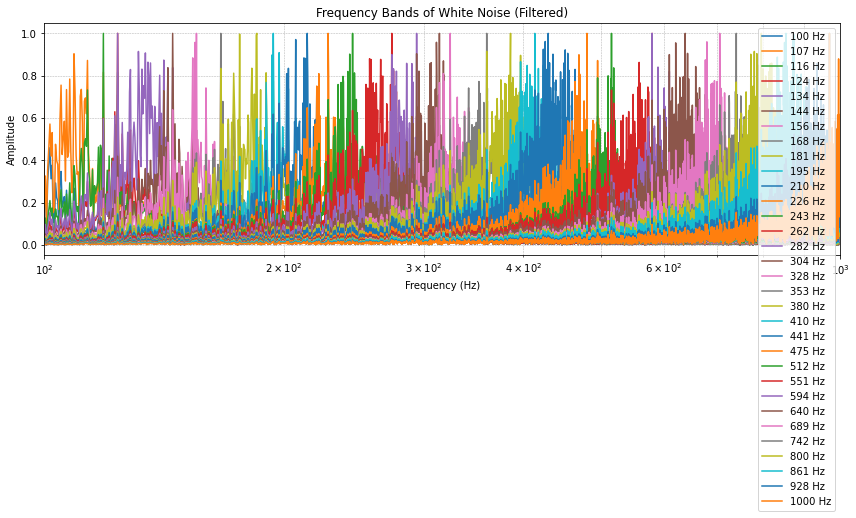

In [18]:
f_min = 100
f_max = 1000
nb_band = 32
BW = 0.15

y, f_center = BPF(f_min, f_max, sample_rate, nb_band, BW)
# Affichage du spectre
plt.figure(figsize=(12, 6))
plt.title("Frequency Bands of White Noise (Filtered)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.xscale('log')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.xlim(f_min, f_max)

for i, y_n in enumerate(y):
    y_fft = np.fft.fft(y_n)
    freqs = np.fft.fftfreq(len(y_n), 1 / sample_rate)
    plt.plot(freqs[:len(freqs)//2], np.abs(y_fft[:len(freqs)//2]) / max(np.abs(y_fft)), label=f"{int(f_center[i])} Hz")
    max_idx = np.argmax(np.abs(y_fft[:len(freqs)//2]))
    max_freq = freqs[max_idx]
    print(f"Band {i+1}: Center Frequency = {f_center[i]:.2f} Hz, Max FFT Amplitude at {max_freq:.2f} Hz")

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


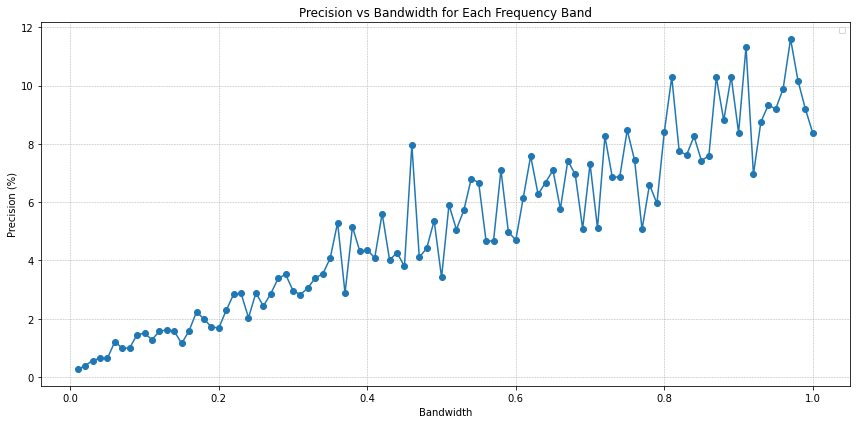

In [28]:
BW_test = np.linspace(0.01, 1, 100)
y_BW_test = []
for BW in BW_test:
    y, f_center = BPF(f_min, f_max, sample_rate, nb_band, BW)
    y_max_freq = []
    for i, y_n in enumerate(y):
        y_fft = np.fft.fft(y_n)
        freqs = np.fft.fftfreq(len(y_n), 1 / sample_rate)
        max_idx = np.argmax(np.abs(y_fft[:len(freqs)//2]))
        max_freq = freqs[max_idx]
        y_max_freq.append(max_freq)
    prec = (np.abs(f_center - np.array(y_max_freq))/f_center) * 100
    y_BW_test.append(prec)

plt.figure(figsize=(12, 6))
plt.title("Precision vs Bandwidth for Each Frequency Band")
plt.xlabel("Bandwidth")
plt.ylabel("Precision (%)")
plt.plot(BW_test, np.mean(y_BW_test, axis=1), marker='o')
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

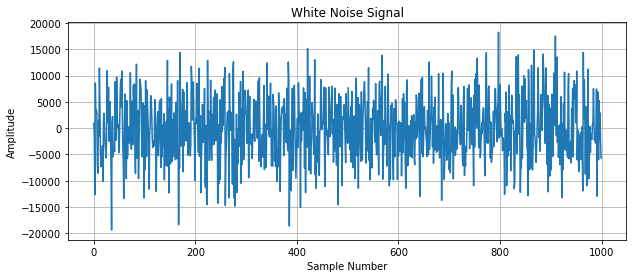

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(noise[:1000])  # Plot the first 1000 samples
plt.title("White Noise Signal")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [1]:
from brian2 import *

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/mathias/.local/lib/python3.10/site-packages/setuptools/_distutils/_msvccompiler.py:12: UserWarning: _get_vc_env is private; find an alternative (pypa/distutils#340)
  warnings.warn(
